# Xác suất thống kê cho AI

## Import and load data

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

df = sns.load_dataset("iris")

## 1. Thống kê mô tả & đặc trưng

### 1.1. Đọc dữ liệu

In [2]:
print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


#### Nhận xét dữ liệu:
- Bộ dữ liệu gồm có 150 hàng và 5 cột
- Trong đó:
    + Cột `species` chứa kiểu dữ liệu `str`
    + Các cột còn lại chứa kiểu dữ liệu `float64`

### 1.2. Tính toán các số liệu thống kê mô tả

#### Biến định hượng

Tính mean, median, mode, var, std, min, max, Q1, Q3, IQR

In [3]:
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
numeric_data = df[numeric_cols]

summary_stats = pd.DataFrame({
    "Mean": numeric_data.mean(),
    "Median": numeric_data.median(),
    "Mode": numeric_data.mode().iloc[0],
    "Variance": numeric_data.var(),
    "Standard Deviation ": numeric_data.std(),
    "Min": numeric_data.min(),
    "Max": numeric_data.max(),
    "Q1": numeric_data.quantile(0.25),
    "Q3": numeric_data.quantile(0.75),
    "IQR": numeric_data.quantile(0.75) - numeric_data.quantile(0.25),
})
print(summary_stats)

                  Mean  Median  Mode  Variance  Standard Deviation   Min  Max  \
sepal_length  5.843333    5.80   5.0  0.685694             0.828066  4.3  7.9   
sepal_width   3.057333    3.00   3.0  0.189979             0.435866  2.0  4.4   
petal_length  3.758000    4.35   1.4  3.116278             1.765298  1.0  6.9   
petal_width   1.199333    1.30   0.2  0.581006             0.762238  0.1  2.5   

               Q1   Q3  IQR  
sepal_length  5.1  6.4  1.3  
sepal_width   2.8  3.3  0.5  
petal_length  1.6  5.1  3.5  
petal_width   0.3  1.8  1.5  


- sepal_length và sepal_width có mean và median không sai biệt nhiều, cho thấy các giá trị phân phối khá cân đối, đối xứng và có thể ít có outliers; còn petal_length và petal_width có chênh lệch nhiều hơn.
- Dựa vào Variance, Std và IQR, ta thấy petal_length có độ phân tán rộng, ít tập trung còn sepal_width thì ổn định hơn.

### 1.3. Tính mean, std theo từng nhóm loài

In [4]:
print(df.groupby("species").mean())

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026


In [5]:
print(df.groupby("species").std())

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


Trong 3 nhóm loài, loài `setosa` khác biệt rõ nhất.
- Ở các cột sepal_length, petal_length, petal_width, nhóm setosa có mean và std thấp nhất; đối với sepal_width thì loài này có số liệu cao nhất.
- Đặc biệt, ở sepal_width và petal_length thì nhóm setosa có sự khác biệt rõ về mean và std so với 2 nhóm còn lại.

## 2. Phân phối xác suất

### 2.1. Histogram và KDE

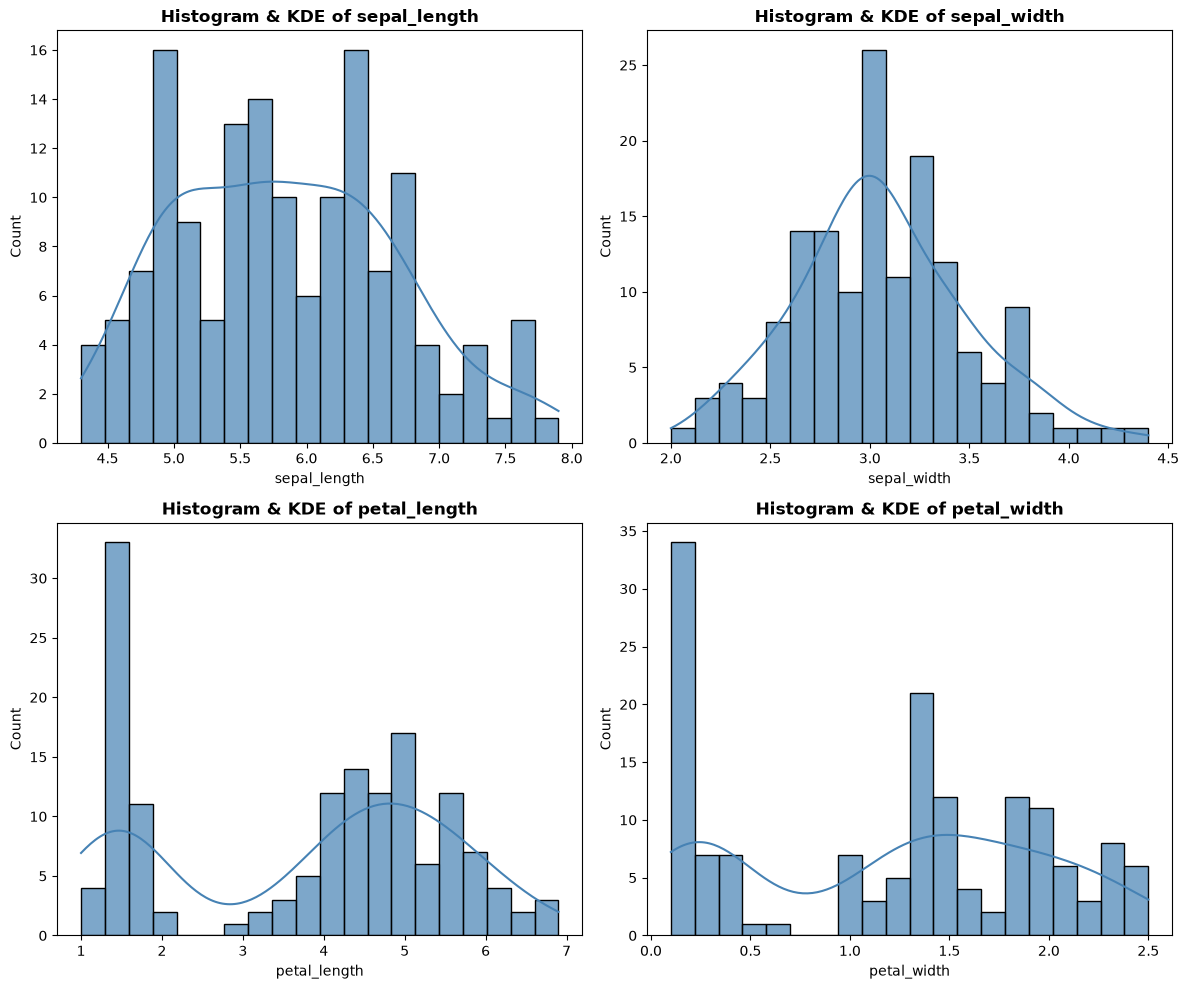

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(numeric_data[col], bins=20, kde=True, color='steelblue', edgecolor='black', alpha=0.7, ax=axes[i])
    axes[i].set_title(f"Histogram & KDE of {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Count", fontsize=10)

plt.tight_layout()
plt.show()

Từ Histogram và KDE ta nhận thấy rằng:
- `sepal_length` có nhiều đỉnh, nhấp nhô ở khoảng giữa, nếu nhìn và KDE thì cũng có dạng hình chuông nhưng không hoàn hảo.
- `sepal_width` có dạng hình chuông đối xứng tương đối tốt, tuân theo phân phối chuẩn và rất ít bị lệch.
- `petal_length` và `petal_width` phân phối thành 2 đỉnh, bị cắt bởi khoảng trống ở giữa, không tuân theo phân phối chuẩn.

### 2.2. Boxplot

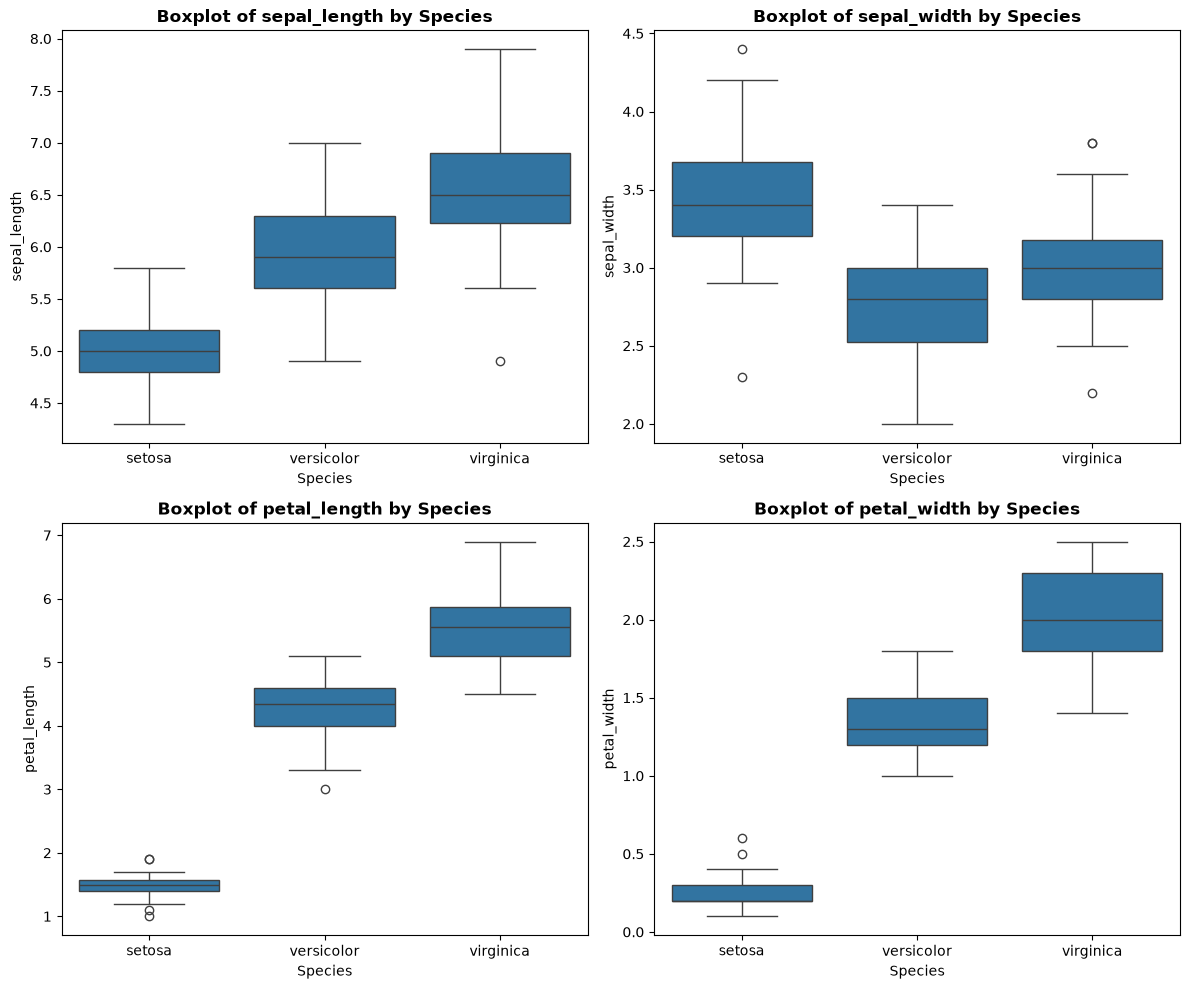

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='species', y=col, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col} by Species", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Species", fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

plt.tight_layout()
plt.show()

Từ các boxplot, ta thấy:
- Về sepal_length thì setosa có giá trị trung bình nhỏ nhất, tiếp đến và versicolor và virginica có sepal dài nhất
- Về sepal width thì setosa lại có chiều rộng lớn nhất, rồi mới đến virginica và versicolor.
- petal_length và petal_width có boxplot tương đối giống nhau, trong đó setosa có giá trị thấp và lại xuất hiện nhiều outliers hơn 2 loài còn lại.

### 2.3. Mô phỏng

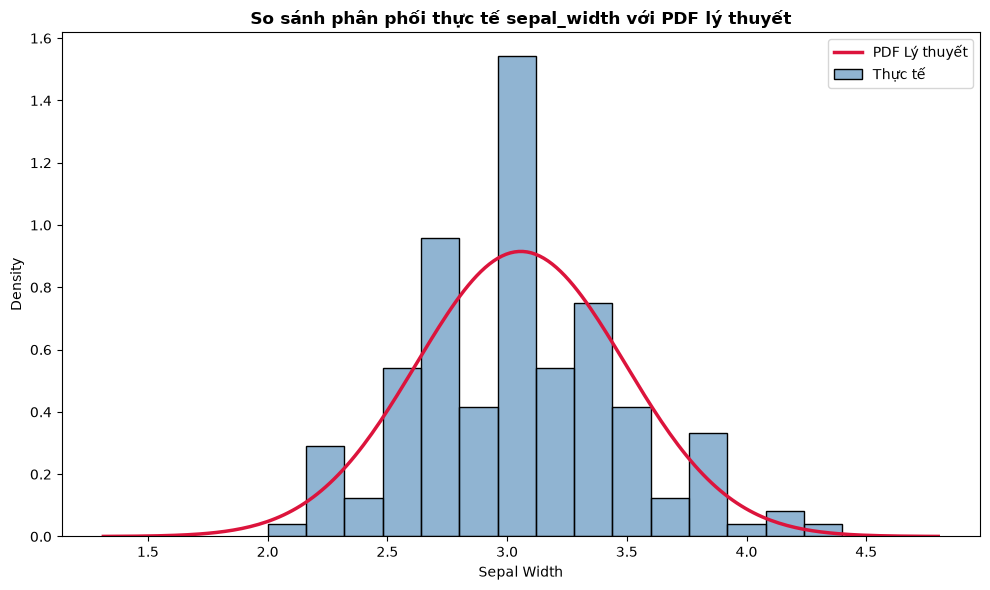

In [8]:
mean_val = df['sepal_width'].mean()
std_val = df['sepal_width'].std()

plt.figure(figsize=(10, 6))

sns.histplot(df['sepal_width'], bins=15, stat='density', 
             color='steelblue', edgecolor='black', alpha=0.6, label='Thực tế')

x = np.linspace(mean_val - 4*std_val, mean_val + 4*std_val, 200)
pdf_theoretical = norm.pdf(x, mean_val, std_val)

plt.plot(x, pdf_theoretical, color='crimson', linewidth=2.5, label='PDF Lý thuyết')

plt.title('So sánh phân phối thực tế sepal_width với PDF lý thuyết', fontsize=12, fontweight='bold')
plt.xlabel('Sepal Width', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

Đồ thị cho thấy dữ liệu mô phỏng từ phân phối chuẩn có xu hướng bám khá sát dữ liệu thực tế ở vùng trung tâm, nhưng vẫn còn khác biệt không ít chỗ. Do đó ta chỉ có thể nói phân phối chuẩn mô tả tương đối tốt xu hướng chung của sepal_width nhưng chưa khớp hoàn toàn với dữ liệu thực tế.

## 3. Phân tích đa biến & tương quan

### 3.1. Ma trận hiệp phương sai và tương quan

In [9]:
cov_matrix = numeric_data.cov()
corr_matrix = numeric_data.corr()

print("Covariance matrix")
print(cov_matrix.round(3))

print("\nCorrelation matrix")
print(corr_matrix.round(3))

Covariance matrix
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         0.686       -0.042         1.274        0.516
sepal_width         -0.042        0.190        -0.330       -0.122
petal_length         1.274       -0.330         3.116        1.296
petal_width          0.516       -0.122         1.296        0.581

Correlation matrix
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


Từ hai ma trận trên, ta thấy được:
- petal_length và petal_width có tương quan dương mạnh nhất.
- sepal_length cũng tương quan khá mạnh với petal_length và petal_width.
- sepal_width có tương quan âm với các biến còn lại.
- Nhóm biến về cánh hoa thể hiện quan hệ rõ hơn nhóm biến về đài hoa.

### 3.2. Heatmap

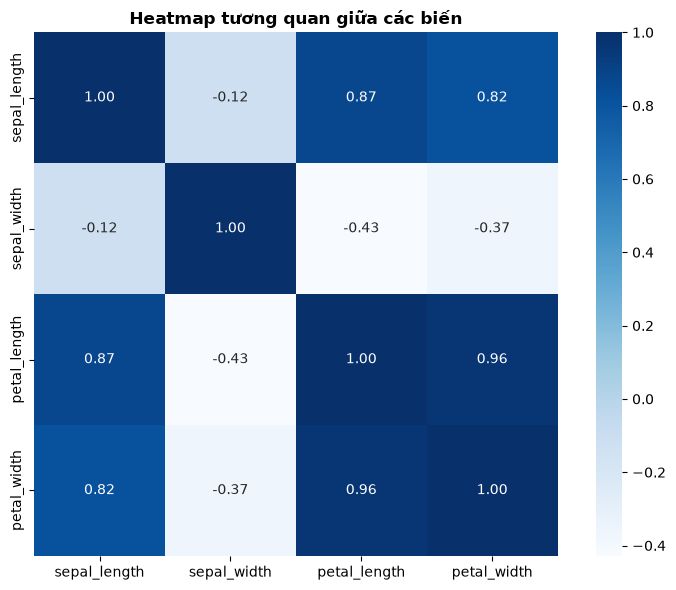

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", square=True)
plt.title("Heatmap tương quan giữa các biến", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

- Heatmap cho thấy petal_length và petal_width có màu đậm nhất nên tương quan mạnh nhất.
- Các cặp sepal_length với petal_length và petal_width cũng có tương quan dương cao.
- Có dấu hiệu đa cộng tuyến giữa petal_length và petal_width do hệ số tương quan rất cao.
- sepal_width có mức tương quan thấp hơn nên ít đóng góp vào quan hệ tuyến tính chung.

### 3.3. Pairplot

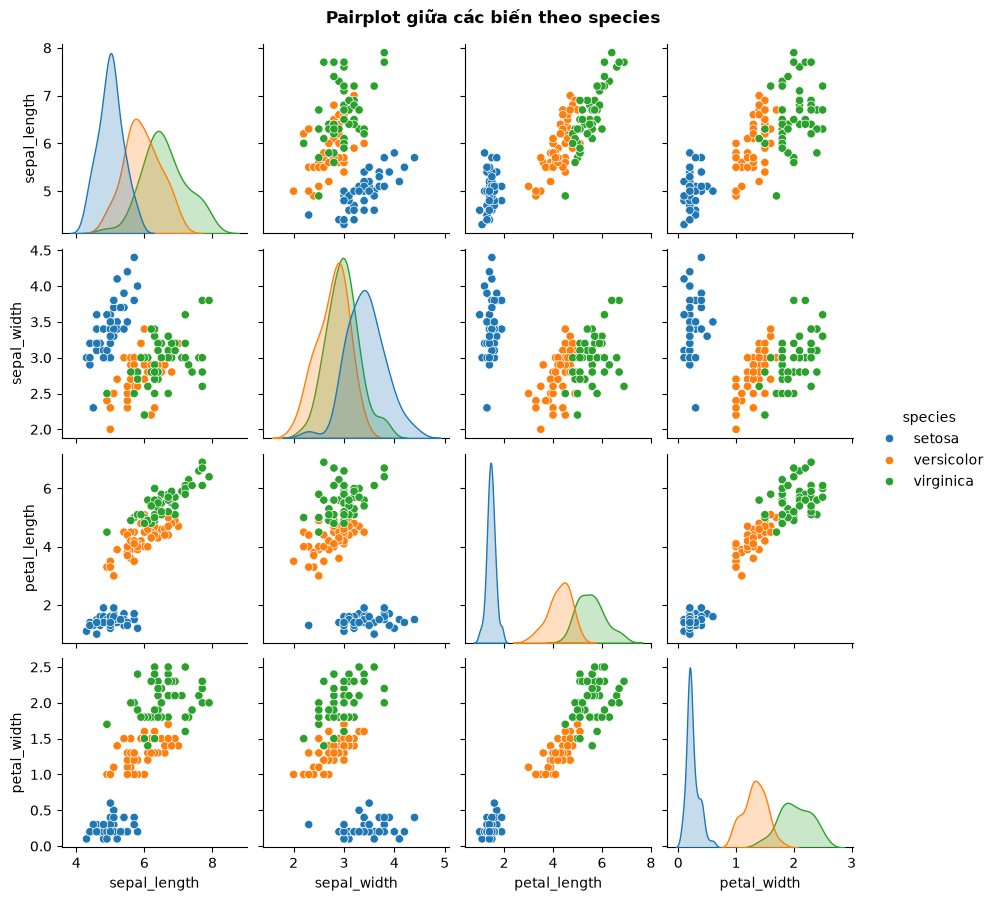

In [11]:
sns.pairplot(df, vars=numeric_cols, hue="species", diag_kind="kde", height=2.2)
plt.suptitle("Pairplot giữa các biến theo species", y=1.02, fontsize=12, fontweight="bold")
plt.show()

- Setosa tách khá rõ so với hai loài còn lại.
- Versicolor và virginica có vùng dữ liệu chồng lấn nhiều hơn.
- Các biến petal_length và petal_width giúp phân biệt các loài tốt nhất.
- Quan hệ giữa petal_length và petal_width gần tuyến tính và tăng cùng chiều.

## 4. Xác suất & Định lý Bayes

### Bài toán chẩn đoán. 
Một bệnh có tỉ lệ mắc trong dân số là P(B) = 0.01. Một xét nghiệm có:
- Độ nhạy (true positive): P(+ | B) = 0.99.
- Dương tính giả (false positive): P(+ | ¬B) = 0.05

### 4.1. Xác suất hậu nghiệm

In [12]:
P_B = 0.01
P_pos_given_B = 0.99
P_pos_given_NB = 0.05

P_pos = P_pos_given_B * P_B + P_pos_given_NB * (1 - P_B)
P_B_given_pos = P_pos_given_B * P_B / P_pos

print(round(P_B_given_pos, 4))

0.1667


- Xác suất mắc bệnh sau khi xét nghiệm dương tính là khoảng 0.1667.
- Kết quả này thấp hơn trực giác ban đầu dù xét nghiệm có độ nhạy cao.
- Nguyên nhân là do bệnh hiếm nên số ca dương tính giả vẫn chiếm tỉ lệ đáng kể.

### 4.2. Khảo sát khi tỉ lệ mắc bệnh thay đổi

In [13]:
P_B_values = np.linspace(0.001, 0.2, 200)

P_pos_values = P_pos_given_B * P_B_values + P_pos_given_not_B * (1 - P_B_values)
P_B_given_pos_values = P_pos_given_B * P_B_values / P_pos_values

plt.figure(figsize=(10, 6))
plt.plot(P_B_values, P_B_given_pos_values, linewidth=2.5)
plt.title("P(B|+) theo tỉ lệ mắc bệnh", fontsize=12, fontweight="bold")
plt.xlabel("P(B)", fontsize=10)
plt.ylabel("P(B|+)", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'P_pos_given_not_B' is not defined

- Khi tỉ lệ mắc bệnh tăng thì xác suất P(B|+) cũng tăng.
- Ở vùng bệnh hiếm, P(B|+) vẫn thấp dù xét nghiệm dương tính.
- Điều này xảy ra vì phần lớn dân số không mắc bệnh nên số dương tính giả có thể nhiều hơn số dương tính thật.
- Khi P(B) đủ lớn, kết quả dương tính trở nên đáng tin cậy hơn.

### 4.3. Bộ lọc Naive Bayes đơn giản

In [ ]:
spam_words = ["free", "win", "money", "offer"]
normal_words = ["meeting", "project", "report", "schedule"]

P_spam = 0.4
P_normal = 0.6

emails = [
    "Dear Ana\n We have a free money offer for you. \n Br. \n Illuminati",
    "Hi Chad,\n For our project, I annouce you our meeting schedule.\n Best wishes. \n Ana",
    "Hi GigaChad,\n Congatulations! You win free report!\n Jk.\n Eve."
]

for email in emails:
    words = email.split()
    spam_score = P_spam
    normal_score = P_normal
    
    for word in words:
        spam_score *= 0.8 if word in spam_words else 0.2
        normal_score *= 0.8 if word in normal_words else 0.2
    
    P_email_spam = spam_score / (spam_score + normal_score)
    print(email, "\nP(spam/email)=", round(P_email_spam, 4),"\n")

- Email chứa nhiều từ như free win money offer có xác suất spam cao hơn.
- Email chứa các từ như meeting project schedule có xác suất spam thấp hơn.
- Mô hình này còn đơn giản vì chỉ dựa trên vài từ khóa.
- Tuy vậy nó minh họa được cách Naive Bayes kết hợp xác suất của từng từ để phân loại email.